# Connectivity vs Time Pressure across all four case neighbourhoods

This experiment repeats Experiment 2.2 across four Amsterdam neighbourhoods that differ in third place accessibility and transport accessibility, forming a 2×2 typology. The four neighbourhoods are: High/High (dense city centre), High Third Place/Low Transport (inner ring), Low Third Place/High Transport (Zuidoost), and Low/Low (outer Nieuw-West).

The spatial context for each neighbourhood is encoded in three input files: road nodes, road edges, and third place locations, extracted from Amsterdam's buurt shapefile and OSM road network 

 These files are loaded manually into the NetLogo model before each neighbourhood's run by updating the file paths directly in the model — this step is not visible in the code below but is what distinguishes the four experiments. 

In [27]:
import pynetlogo
import pandas as pd
import itertools
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 1. Explicitly point to the libjvm.dylib file inside NetLogo's application package
# Path on GIS DESKTOP
jvm_path = "C:/Program Files/NetLogo 6.4.0/runtime/bin/server/jvm.dll"
netlogo_home = "C:/Program Files/NetLogo 6.4.0"

#Path on Mac Laptop
# jvm_path = "/Applications/NetLogo 6.4.0/runtime/Contents/Home/lib/server/libjvm.dylib"
# netlogo_home="/Applications/NetLogo 6.4.0"

netlogo = pynetlogo.NetLogoLink(
    gui=False,
    netlogo_home=netlogo_home,
    jvm_path=jvm_path 
)

# Path in GIS DESKTOP
model_path = "C:/Users/15177459/Desktop/Bachelor-Thesis/Netlogo/third_place_attributes.nlogo"

# Path in Mac Laptop
# model_path = "/Users/tonyvo/Desktop/Thesis/Bachelor-Thesis/Netlogo/third_place_attributes.nlogo"

netlogo.load_model(model_path)
netlogo.command("setup")
netlogo.report("count places")

33.0

# First Heatmap: High Transport, High Third Place

In [2]:
# Attribute based choice ON
parameter_grid = {
    "number-of-people": [200],
    "baseline-stop-probability": [10, 20, 30, 40],
    "third-place-search-radius": [1, 2, 5, 10],
    "route-third-place-sample-size": [50],
    "rigid-dwell-time": [30],
    "medium-dwell-time": [45],
    "flexible-dwell-time": [60],
    "encounter-odds-increment": [0.10],
    "encounter-weight": [5],
    "social-feedback?": [True],
    "attribute-based-choice?": [True]
}

reporters = [
    "visits-per-person",
    "average-stop-probability",
    "average-social-encounters",
    "average-social-odds-ratio",
    "total-co-presence",
    "co-presence-per-visit",
    "visited-places-count",
    "places-with-co-presence",
    "visit-concentration",
    "average-visited-place-affordability",
    "average-visited-place-welcomingness"
]

results = []

keys = list(parameter_grid.keys())
values = list(parameter_grid.values())

run_id = 0

for combination in itertools.product(*values):
    params = dict(zip(keys, combination))
    
    for seed in range(1, 21):  # 20 repetitions
        run_id += 1
        
        netlogo.command(f"random-seed {seed}")
        
        for parameter, value in params.items():
            if isinstance(value, bool):
                value = "true" if value else "false"
            netlogo.command(f"set {parameter} {value}")
        
        netlogo.command("setup")
        netlogo.command("repeat 1000 [ go ]")
        
        row = {
            "experiment": "attribute_test",
            "run_id": run_id,
            "seed": seed,
            **params,
        }
        
        for reporter in reporters:
            row[reporter] = netlogo.report(reporter)
        
        results.append(row)

exphi_hi = pd.DataFrame(results)

print(exphi_hi.shape)
exphi_hi.head()

(320, 25)


,experiment,run_id,seed,number-of-people,baseline-stop-probability,third-place-search-radius,route-third-place-sample-size,rigid-dwell-time,medium-dwell-time,flexible-dwell-time,...,average-stop-probability,average-social-encounters,average-social-odds-ratio,total-co-presence,co-presence-per-visit,visited-places-count,places-with-co-presence,visit-concentration,average-visited-place-affordability,average-visited-place-welcomingness
0,attribute_test,1,1,200,10,1,50,30,45,60,...,8.983445,3.25,1.2560,2247.0,13.140351,36.0,15.0,0.122807,0.592335,0.677218
1,attribute_test,2,2,200,10,1,50,30,45,60,...,8.564894,2.45,1.2190,1832.0,11.819355,39.0,14.0,0.083871,0.619892,0.654527
2,attribute_test,3,3,200,10,1,50,30,45,60,...,8.994830,2.55,1.2495,2276.0,14.875817,34.0,13.0,0.098039,0.650876,0.605243
3,attribute_test,4,4,200,10,1,50,30,45,60,...,8.667442,2.60,1.2270,2281.0,13.658683,33.0,16.0,0.083832,0.624168,0.615319
4,attribute_test,5,5,200,10,1,50,30,45,60,...,8.651313,2.90,1.2285,2337.0,13.994012,34.0,14.0,0.107784,0.546683,0.588554


In [3]:
grouped_hi_hi = exphi_hi.groupby(["baseline-stop-probability", "third-place-search-radius"]).agg(
    co_presence_mean = ("total-co-presence", "mean"),
    co_presence_std = ("total-co-presence", "std"),
    visits_mean = ("visits-per-person", "mean"),
    encounter_mean = ("average-social-encounters", "mean"),
    concentration_mean = ("visit-concentration", "mean"),
    copresence_per_visit_mean = ("co-presence-per-visit", "mean")
).reset_index()

grouped_hi_hi

,baseline-stop-probability,third-place-search-radius,co_presence_mean,co_presence_std,visits_mean,encounter_mean,concentration_mean,copresence_per_visit_mean
0,10,1,1797.75,423.285132,0.76350,2.3275,0.095442,11.690120
1,10,2,2887.70,754.079229,0.75750,4.4250,0.149964,18.876633
2,10,5,3931.20,898.218154,0.70625,7.2150,0.217125,27.541046
3,10,10,3916.05,871.859143,0.70500,7.1425,0.216182,27.514576
4,20,1,6032.45,769.370110,1.53950,9.6675,0.089077,19.555364
5,20,2,8725.20,1182.050475,1.47050,18.4800,0.153584,29.618426
6,20,5,10221.85,1231.702941,1.36875,28.7825,0.208248,37.262307
7,20,10,10303.50,1445.408429,1.34850,29.0250,0.218150,38.053014
8,30,1,10807.85,1488.441901,2.20900,20.2475,0.089104,24.398507
9,30,2,13600.05,1220.242188,2.06425,36.1950,0.149977,32.913811


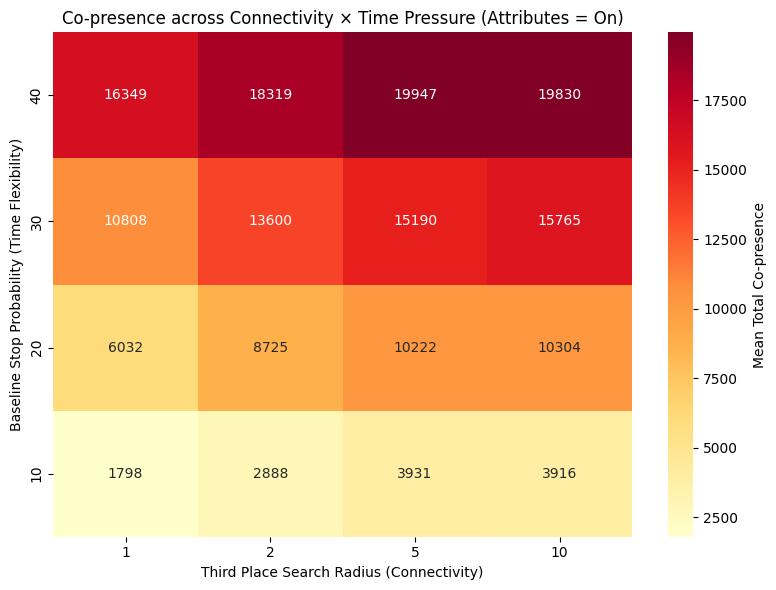

In [5]:
pivot = grouped_hi_hi.pivot(
    index="baseline-stop-probability",
    columns="third-place-search-radius",
    values="co_presence_mean"
)

# Flip so high stop probability is at top (more intuitive reading)
pivot = pivot.sort_index(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    ax=ax,
    cbar_kws={"label": "Mean Total Co-presence"}
)
ax.set_title("Co-presence across Connectivity × Time Pressure (Attributes = On)")
ax.set_xlabel("Third Place Search Radius (Connectivity)")
ax.set_ylabel("Baseline Stop Probability (Time Flexibility)")
plt.tight_layout()


In [6]:
path_a = grouped_hi_hi[
    (grouped_hi_hi["baseline-stop-probability"] == 40) &
    (grouped_hi_hi["third-place-search-radius"] == 1)
]["co_presence_mean"].values[0]

path_b = grouped_hi_hi[
    (grouped_hi_hi["baseline-stop-probability"] == 10) &
    (grouped_hi_hi["third-place-search-radius"] == 10)
]["co_presence_mean"].values[0]

print(f"Path A (low connectivity, high flexibility): {path_a:.1f}")
print(f"Path B (high connectivity, high time pressure): {path_b:.1f}")
print(f"Difference: {path_a - path_b:.1f}")

Path A (low connectivity, high flexibility): 16348.7
Path B (high connectivity, high time pressure): 3916.1
Difference: 12432.7


In [ ]:
baseline = grouped_hi_hi[
    (grouped_hi_hi["baseline-stop-probability"] == 30) &
    (grouped_hi_hi["third-place-search-radius"] == 2)
]["co_presence_mean"].values[0]  # your original fixed condition

dispersal_only = grouped_hi_hi[
    (grouped_hi_hi["baseline-stop-probability"] == 30) &  # pressure held constant
    (grouped_hi_hi["third-place-search-radius"] == 10)    # only radius increases
]["co_presence_mean"].values[0]

pressure_only = grouped_hi_hi[
    (grouped_hi_hi["baseline-stop-probability"] == 10) &  # only pressure increases
    (grouped_hi_hi["third-place-search-radius"] == 2)     # radius held constant
]["co_presence_mean"].values[0]

combined = grouped_hi_hi[
    (grouped_hi_hi["baseline-stop-probability"] == 10) &
    (grouped_hi_hi["third-place-search-radius"] == 10)
]["co_presence_mean"].values[0]


# effect = scenario value - baseline value
print(f"Baseline: {baseline:.1f}")
print(f"Dispersal effect alone: {dispersal_only - baseline:.1f}")
print(f"Time pressure effect alone: {pressure_only - baseline:.1f}")
print(f"Combined effect: {combined-baseline:.1f}")


Baseline: 13600.0
Dispersal effect alone: 2164.5
Time pressure effect alone: -10712.3
Combined effect: -9684.0


# Second Heatmap: High Transport Low Third Place

In [ ]:
# Attribute based choice ON
parameter_grid = {
    "number-of-people": [200],
    "baseline-stop-probability": [10, 20, 30, 40],
    "third-place-search-radius": [1, 2, 5, 10],
    "route-third-place-sample-size": [50],
    "rigid-dwell-time": [30],
    "medium-dwell-time": [45],
    "flexible-dwell-time": [60],
    "encounter-odds-increment": [0.10],
    "encounter-weight": [5],
    "social-feedback?": [True],
    "attribute-based-choice?": [True]
}

reporters = [
    "visits-per-person",
    "average-stop-probability",
    "average-social-encounters",
    "average-social-odds-ratio",
    "total-co-presence",
    "co-presence-per-visit",
    "visited-places-count",
    "places-with-co-presence",
    "visit-concentration",
    "average-visited-place-affordability",
    "average-visited-place-welcomingness"
]

results = []

keys = list(parameter_grid.keys())
values = list(parameter_grid.values())

run_id = 0

for combination in itertools.product(*values):
    params = dict(zip(keys, combination))
    
    for seed in range(1, 21):  # 20 repetitions
        run_id += 1
        
        netlogo.command(f"random-seed {seed}")
        
        for parameter, value in params.items():
            if isinstance(value, bool):
                value = "true" if value else "false"
            netlogo.command(f"set {parameter} {value}")
        
        netlogo.command("setup")
        netlogo.command("repeat 1000 [ go ]")
        
        row = {
            "experiment": "attribute_test",
            "run_id": run_id,
            "seed": seed,
            **params,
        }
        
        for reporter in reporters:
            row[reporter] = netlogo.report(reporter)
        
        results.append(row)

exphi_low = pd.DataFrame(results)



In [12]:
print(exphi_low.shape)
exphi_low.head()

(320, 25)


,experiment,run_id,seed,number-of-people,baseline-stop-probability,third-place-search-radius,route-third-place-sample-size,rigid-dwell-time,medium-dwell-time,flexible-dwell-time,...,average-stop-probability,average-social-encounters,average-social-odds-ratio,total-co-presence,co-presence-per-visit,visited-places-count,places-with-co-presence,visit-concentration,average-visited-place-affordability,average-visited-place-welcomingness
0,attribute_test,1,1,200,10,1,50,30,45,60,...,7.541258,0.75,1.057,515.0,8.306452,17.0,3.0,0.193548,0.599622,0.510331
1,attribute_test,2,2,200,10,1,50,30,45,60,...,7.380720,0.35,1.035,374.0,7.056604,19.0,5.0,0.150943,0.410272,0.533254
2,attribute_test,3,3,200,10,1,50,30,45,60,...,7.553555,0.95,1.082,815.0,11.985294,19.0,3.0,0.220588,0.652763,0.538795
3,attribute_test,4,4,200,10,1,50,30,45,60,...,7.641284,0.80,1.079,577.0,9.306452,17.0,5.0,0.225806,0.360301,0.517270
4,attribute_test,5,5,200,10,1,50,30,45,60,...,7.245523,0.40,1.039,426.0,8.520000,19.0,5.0,0.260000,0.609095,0.521468


In [13]:
grouped_hi_low = exphi_low.groupby(["baseline-stop-probability", "third-place-search-radius"]).agg(
    co_presence_mean = ("total-co-presence", "mean"),
    co_presence_std = ("total-co-presence", "std"),
    visits_mean = ("visits-per-person", "mean"),
    encounter_mean = ("average-social-encounters", "mean"),
    concentration_mean = ("visit-concentration", "mean"),
    copresence_per_visit_mean = ("co-presence-per-visit", "mean")
).reset_index()

grouped_hi_low

,baseline-stop-probability,third-place-search-radius,co_presence_mean,co_presence_std,visits_mean,encounter_mean,concentration_mean,copresence_per_visit_mean
0,10,1,466.35,202.133951,0.27075,0.5925,0.211877,8.418678
1,10,2,462.25,171.807994,0.29725,0.5825,0.162125,7.679202
2,10,5,532.50,195.100649,0.28025,0.6700,0.187795,9.409001
3,10,10,643.15,265.270721,0.23925,0.8250,0.236793,13.237359
4,20,1,1629.80,561.657378,0.57750,2.4325,0.193569,13.804335
5,20,2,1619.55,560.883464,0.60175,2.2450,0.153422,13.251929
6,20,5,1725.95,408.853400,0.51475,2.5200,0.178495,16.682296
7,20,10,1898.75,389.338423,0.45650,2.9225,0.211457,20.788993
8,30,1,3359.85,920.860826,0.87475,5.9650,0.187686,18.984566
9,30,2,3105.85,840.491227,0.88175,4.9325,0.150470,17.352053


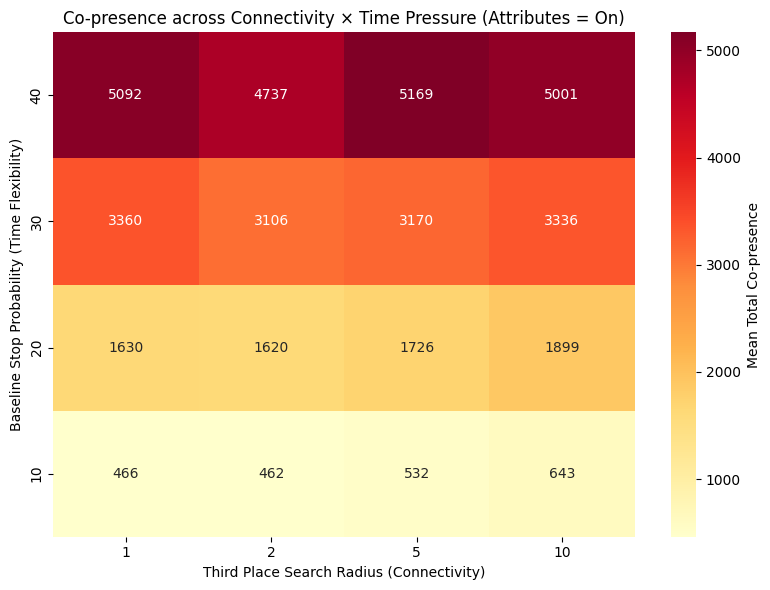

In [14]:
pivot = grouped_hi_low.pivot(
    index="baseline-stop-probability",
    columns="third-place-search-radius",
    values="co_presence_mean"
)

# Flip so high stop probability is at top (more intuitive reading)
pivot = pivot.sort_index(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    ax=ax,
    cbar_kws={"label": "Mean Total Co-presence"}
)
ax.set_title("Co-presence across Connectivity × Time Pressure (Attributes = On)")
ax.set_xlabel("Third Place Search Radius (Connectivity)")
ax.set_ylabel("Baseline Stop Probability (Time Flexibility)")
plt.tight_layout()


In [15]:
path_a = grouped_hi_low[
    (grouped_hi_low["baseline-stop-probability"] == 40) &
    (grouped_hi_low["third-place-search-radius"] == 1)
]["co_presence_mean"].values[0]

path_b = grouped_hi_low[
    (grouped_hi_low["baseline-stop-probability"] == 10) &
    (grouped_hi_low["third-place-search-radius"] == 10)
]["co_presence_mean"].values[0]

print(f"Path A (low connectivity, high flexibility): {path_a:.1f}")
print(f"Path B (high connectivity, high time pressure): {path_b:.1f}")
print(f"Difference: {path_a - path_b:.1f}")

baseline = grouped_hi_low[
    (grouped_hi_low["baseline-stop-probability"] == 30) &
    (grouped_hi_low["third-place-search-radius"] == 2)
]["co_presence_mean"].values[0]  # your original fixed condition

dispersal_only = grouped_hi_low[
    (grouped_hi_low["baseline-stop-probability"] == 30) &  # pressure held constant
    (grouped_hi_low["third-place-search-radius"] == 10)    # only radius increases
]["co_presence_mean"].values[0]

pressure_only = grouped_hi_low[
    (grouped_hi_low["baseline-stop-probability"] == 10) &  # only pressure increases
    (grouped_hi_low["third-place-search-radius"] == 2)     # radius held constant
]["co_presence_mean"].values[0]

combined = grouped_hi_low[
    (grouped_hi_low["baseline-stop-probability"] == 10) &
    (grouped_hi_low["third-place-search-radius"] == 10)
]["co_presence_mean"].values[0]

print(f"Baseline: {baseline:.1f}")
print(f"Dispersal effect alone: {dispersal_only - baseline:.1f}")
print(f"Time pressure effect alone: {pressure_only - baseline:.1f}")
print(f"Combined effect: {combined-baseline:.1f}")


Path A (low connectivity, high flexibility): 5091.6
Path B (high connectivity, high time pressure): 643.1
Difference: 4448.5
Baseline: 3105.8
Dispersal effect alone: 230.5
Time pressure effect alone: -2643.6
Combined effect: -2462.7


# Third Heatmap: Low Transport High Third Place


In [17]:
# Attribute based choice ON
parameter_grid = {
    "number-of-people": [200],
    "baseline-stop-probability": [10, 20, 30, 40],
    "third-place-search-radius": [1, 2, 5, 10],
    "route-third-place-sample-size": [50],
    "rigid-dwell-time": [30],
    "medium-dwell-time": [45],
    "flexible-dwell-time": [60],
    "encounter-odds-increment": [0.10],
    "encounter-weight": [5],
    "social-feedback?": [True],
    "attribute-based-choice?": [True]
}

reporters = [
    "visits-per-person",
    "average-stop-probability",
    "average-social-encounters",
    "average-social-odds-ratio",
    "total-co-presence",
    "co-presence-per-visit",
    "visited-places-count",
    "places-with-co-presence",
    "visit-concentration",
    "average-visited-place-affordability",
    "average-visited-place-welcomingness"
]

results = []

keys = list(parameter_grid.keys())
values = list(parameter_grid.values())

run_id = 0

for combination in itertools.product(*values):
    params = dict(zip(keys, combination))
    
    for seed in range(1, 21):  # 20 repetitions
        run_id += 1
        
        netlogo.command(f"random-seed {seed}")
        
        for parameter, value in params.items():
            if isinstance(value, bool):
                value = "true" if value else "false"
            netlogo.command(f"set {parameter} {value}")
        
        netlogo.command("setup")
        netlogo.command("repeat 1000 [ go ]")
        
        row = {
            "experiment": "attribute_test",
            "run_id": run_id,
            "seed": seed,
            **params,
        }
        
        for reporter in reporters:
            row[reporter] = netlogo.report(reporter)
        
        results.append(row)

explow_hi = pd.DataFrame(results)



In [19]:
print(explow_hi.shape)
explow_hi.head()

(320, 25)


,experiment,run_id,seed,number-of-people,baseline-stop-probability,third-place-search-radius,route-third-place-sample-size,rigid-dwell-time,medium-dwell-time,flexible-dwell-time,...,average-stop-probability,average-social-encounters,average-social-odds-ratio,total-co-presence,co-presence-per-visit,visited-places-count,places-with-co-presence,visit-concentration,average-visited-place-affordability,average-visited-place-welcomingness
0,attribute_test,1,1,200,10,1,50,30,45,60,...,7.522806,0.45,1.0450,312.0,4.105263,27.0,3.0,0.144737,0.613075,0.528504
1,attribute_test,2,2,200,10,1,50,30,45,60,...,7.322099,0.40,1.0400,314.0,4.301370,26.0,5.0,0.109589,0.598414,0.681677
2,attribute_test,3,3,200,10,1,50,30,45,60,...,8.053264,2.15,1.1325,1480.0,14.230769,24.0,7.0,0.230769,0.700262,0.654565
3,attribute_test,4,4,200,10,1,50,30,45,60,...,8.083631,1.25,1.1000,1077.0,11.103093,25.0,8.0,0.164948,0.639630,0.552001
4,attribute_test,5,5,200,10,1,50,30,45,60,...,7.767146,1.80,1.1200,1420.0,15.268817,27.0,5.0,0.247312,0.579013,0.591836


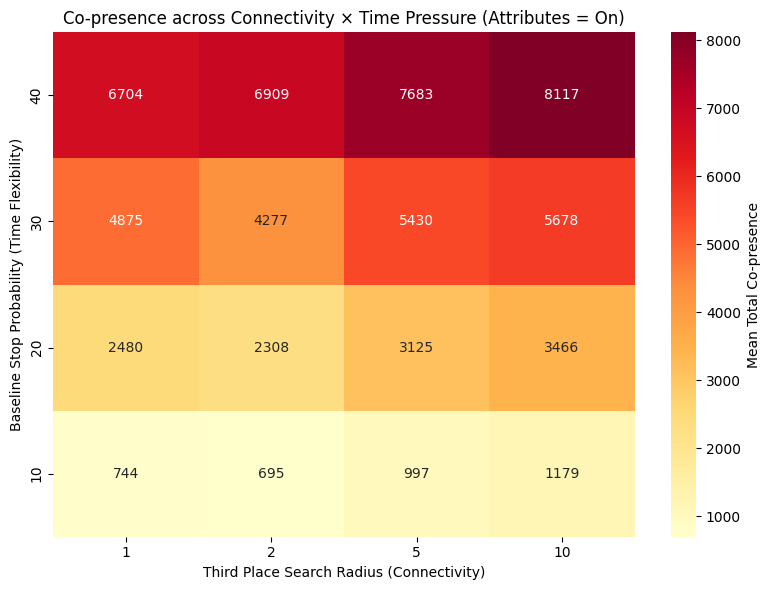

In [ ]:
grouped_low_hi = explow_hi.groupby(["baseline-stop-probability", "third-place-search-radius"]).agg(
    co_presence_mean = ("total-co-presence", "mean"),
    co_presence_std = ("total-co-presence", "std"),
    visits_mean = ("visits-per-person", "mean"),
    encounter_mean = ("average-social-encounters", "mean"),
    concentration_mean = ("visit-concentration", "mean"),
    copresence_per_visit_mean = ("co-presence-per-visit", "mean")
).reset_index()



pivot = grouped_low_hi.pivot(
    index="baseline-stop-probability",
    columns="third-place-search-radius",
    values="co_presence_mean"
)

# Flip so high stop probability is at top (more intuitive reading)
pivot = pivot.sort_index(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    ax=ax,
    cbar_kws={"label": "Mean Total Co-presence"}
)
ax.set_title("Co-presence across Connectivity × Time Pressure (Attributes = On)")
ax.set_xlabel("Third Place Search Radius (Connectivity)")
ax.set_ylabel("Baseline Stop Probability (Time Flexibility)")
plt.tight_layout()


In [1]:
grouped_hi_low

NameError: name 'grouped_hi_low' is not defined

In [21]:
path_a = grouped_low_hi[
    (grouped_low_hi["baseline-stop-probability"] == 40) &
    (grouped_low_hi["third-place-search-radius"] == 1)
]["co_presence_mean"].values[0]

path_b = grouped_low_hi[
    (grouped_low_hi["baseline-stop-probability"] == 10) &
    (grouped_low_hi["third-place-search-radius"] == 10)
]["co_presence_mean"].values[0]

print(f"Path A (low connectivity, high flexibility): {path_a:.1f}")
print(f"Path B (high connectivity, high time pressure): {path_b:.1f}")
print(f"Difference: {path_a - path_b:.1f}")

baseline = grouped_low_hi[
    (grouped_low_hi["baseline-stop-probability"] == 30) &
    (grouped_low_hi["third-place-search-radius"] == 2)
]["co_presence_mean"].values[0]

dispersal_only = grouped_low_hi[
    (grouped_low_hi["baseline-stop-probability"] == 30) &  # pressure held constant
    (grouped_low_hi["third-place-search-radius"] == 10)    # only radius increases
]["co_presence_mean"].values[0]

pressure_only = grouped_low_hi[
    (grouped_low_hi["baseline-stop-probability"] == 10) &  # only pressure increases
    (grouped_low_hi["third-place-search-radius"] == 2)     # radius held constant
]["co_presence_mean"].values[0]

combined = grouped_low_hi[
    (grouped_low_hi["baseline-stop-probability"] == 10) &
    (grouped_low_hi["third-place-search-radius"] == 10)
]["co_presence_mean"].values[0]

print(f"Baseline: {baseline:.1f}")
print(f"Dispersal effect alone: {dispersal_only - baseline:.1f}")
print(f"Time pressure effect alone: {pressure_only - baseline:.1f}")
print(f"Combined effect: {combined - baseline:.1f}")

Path A (low connectivity, high flexibility): 6703.6
Path B (high connectivity, high time pressure): 1179.1
Difference: 5524.5
Baseline: 4276.8
Dispersal effect alone: 1401.4
Time pressure effect alone: -3581.4
Combined effect: -3097.7


# Fourth Heatmap: Low Transport Low Third Place

In [29]:
# Attribute based choice ON
parameter_grid = {
    "number-of-people": [200],
    "baseline-stop-probability": [10, 20, 30, 40],
    "third-place-search-radius": [1, 2, 5, 10],
    "route-third-place-sample-size": [50],
    "rigid-dwell-time": [30],
    "medium-dwell-time": [45],
    "flexible-dwell-time": [60],
    "encounter-odds-increment": [0.10],
    "encounter-weight": [5],
    "social-feedback?": [True],
    "attribute-based-choice?": [True]
}

reporters = [
    "visits-per-person",
    "average-stop-probability",
    "average-social-encounters",
    "average-social-odds-ratio",
    "total-co-presence",
    "co-presence-per-visit",
    "visited-places-count",
    "places-with-co-presence",
    "visit-concentration",
    "average-visited-place-affordability",
    "average-visited-place-welcomingness"
]

results = []

keys = list(parameter_grid.keys())
values = list(parameter_grid.values())

run_id = 0

for combination in itertools.product(*values):
    params = dict(zip(keys, combination))
    
    for seed in range(1, 21):  # 20 repetitions
        run_id += 1
        
        netlogo.command(f"random-seed {seed}")
        
        for parameter, value in params.items():
            if isinstance(value, bool):
                value = "true" if value else "false"
            netlogo.command(f"set {parameter} {value}")
        
        netlogo.command("setup")
        netlogo.command("repeat 1000 [ go ]")
        
        row = {
            "experiment": "attribute_test",
            "run_id": run_id,
            "seed": seed,
            **params,
        }
        
        for reporter in reporters:
            row[reporter] = netlogo.report(reporter)
        
        results.append(row)

explow_low = pd.DataFrame(results)



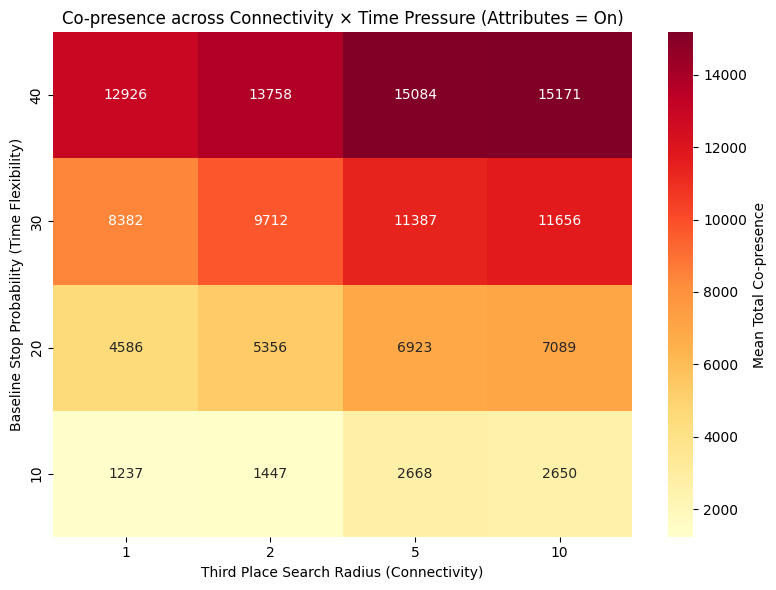

In [30]:
grouped_low_low = explow_low.groupby(["baseline-stop-probability", "third-place-search-radius"]).agg(
    co_presence_mean = ("total-co-presence", "mean"),
    co_presence_std = ("total-co-presence", "std"),
    visits_mean = ("visits-per-person", "mean"),
    encounter_mean = ("average-social-encounters", "mean"),
    concentration_mean = ("visit-concentration", "mean"),
    copresence_per_visit_mean = ("co-presence-per-visit", "mean")
).reset_index()


pivot = grouped_low_low.pivot(
    index="baseline-stop-probability",
    columns="third-place-search-radius",
    values="co_presence_mean"
)

# Flip so high stop probability is at top (more intuitive reading)
pivot = pivot.sort_index(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    ax=ax,
    cbar_kws={"label": "Mean Total Co-presence"}
)
ax.set_title("Co-presence across Connectivity × Time Pressure (Attributes = On)")
ax.set_xlabel("Third Place Search Radius (Connectivity)")
ax.set_ylabel("Baseline Stop Probability (Time Flexibility)")
plt.tight_layout()


In [25]:
path_a = grouped_low_low[
    (grouped_low_low["baseline-stop-probability"] == 40) &
    (grouped_low_low["third-place-search-radius"] == 1)
]["co_presence_mean"].values[0]

path_b = grouped_low_low[
    (grouped_low_low["baseline-stop-probability"] == 10) &
    (grouped_low_low["third-place-search-radius"] == 10)
]["co_presence_mean"].values[0]

print(f"Path A (low connectivity, high flexibility): {path_a:.1f}")
print(f"Path B (high connectivity, high time pressure): {path_b:.1f}")
print(f"Difference: {path_a - path_b:.1f}")

baseline = grouped_low_low[
    (grouped_low_low["baseline-stop-probability"] == 30) &
    (grouped_low_low["third-place-search-radius"] == 2)
]["co_presence_mean"].values[0]

dispersal_only = grouped_low_low[
    (grouped_low_low["baseline-stop-probability"] == 30) &  # pressure held constant
    (grouped_low_low["third-place-search-radius"] == 10)    # only radius increases
]["co_presence_mean"].values[0]

pressure_only = grouped_low_low[
    (grouped_low_low["baseline-stop-probability"] == 10) &  # only pressure increases
    (grouped_low_low["third-place-search-radius"] == 2)     # radius held constant
]["co_presence_mean"].values[0]

combined = grouped_low_low[
    (grouped_low_low["baseline-stop-probability"] == 10) &
    (grouped_low_low["third-place-search-radius"] == 10)
]["co_presence_mean"].values[0]

print(f"Baseline: {baseline:.1f}")
print(f"Dispersal effect alone: {dispersal_only - baseline:.1f}")
print(f"Time pressure effect alone: {pressure_only - baseline:.1f}")
print(f"Combined effect: {combined - baseline:.1f}")

Path A (low connectivity, high flexibility): 12926.0
Path B (high connectivity, high time pressure): 2649.8
Difference: 10276.1
Baseline: 9711.9
Dispersal effect alone: 1943.8
Time pressure effect alone: -8264.9
Combined effect: -7062.0
